# Frequency-only sweep: direct MMNN updates versus periodic refits

This notebook changes only the oscillation frequency

$$
\omega/\pi\in\{1,4,8\}
$$

in the two-player non-potential game

$$
b_\omega(x)=d(x)+q_\omega(x),
$$

$$
d(x)=\begin{pmatrix}-\kappa x_1\\-\kappa x_2\end{pmatrix},
\qquad
q_\omega(x)=\begin{pmatrix}A\sin(\omega x_2)\\-A\sin(\omega x_1)\end{pmatrix}.
$$

All sample counts, initial particles, MMNN architecture, time controls, tangent-subset size, SVD tolerance, and random seed remain fixed. The sweep is an explicit notebook loop: for every $\omega$, it constructs the game, constructs the standard package configurations, and calls the package runners directly. No sweep-specific configuration or sweep runner is defined.

In [ ]:
from pathlib import Path
import copy
import math
import shutil

import matplotlib.pyplot as plt
import numpy as np
import torch

# Locate this project for numerical output.
repo_root = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / 'pyproject.toml').is_file() and (path / 'src' / 'dtb_game').is_dir()),
    None,
)
if repo_root is None:
    raise FileNotFoundError('Open this notebook from the project checkout.')

from dtb_game import (ExperimentConfig, NetworkRefitConfig, OscillatoryNonpotentialGame, RefitDTBConfig, ResidualMMNN, evaluate_dtb_projection, rk4_flow, run_experiment, run_refit_dtb)
from dtb_game.projection import (flat_parameters)
from dtb_game.models import (count_parameters)
from dtb_game.utils import (resolve_device, resolve_dtype, sample_uniform_box, warmup_cuda, write_csv)

output_dir = repo_root / 'results' / 'omega_direct_vs_periodic_refit'
output_dir.mkdir(parents=True, exist_ok=True)
print('repository:', repo_root)
print('output:', output_dir)

## 1. Fixed controls: only $\omega$ is swept

The direct method uses a newly selected random tangent subset at every outer step and applies

$$
\theta_{k+1}[S_k]=\theta_k[S_k]+h\alpha_k.
$$

The periodic method uses the same ordinary-step random-coordinate schedule, leaves $\theta$ fixed between refits, uses the full tangent basis on scheduled refit steps, and then fits the entire MMNN to the updated particles. Both methods start from the same particles and the same identity-initialized residual MMNN.

In [2]:
# The only swept control.
OMEGA_MULTIPLIERS = (1.0, 4.0, 8.0)

# Fixed game and Monte Carlo controls.
SEED = 2026
KAPPA = 1.0
AMPLITUDE = 1.0
TRAINING_SIZE = 10000
VALIDATION_SIZE = 10000
VALIDATION_SEED = 9026

# Fixed outer integration and RK4 controls.
STEP_SIZE = 0.005
FINAL_TIME = 1
RK4_REFERENCE_STEP = 0.000125

# Fixed residual-MMNN and tangent-projection controls.
MMNN_WIDTH = 12
MMNN_RANK = 12
MMNN_DEPTH = 3
ACTIVATION = 'tanh'
RANDOM_TANGENT_SIZE = 512
SVD_RTOL = 1e-5
JACOBIAN_CHUNK = 1024

# Fixed periodic full-basis refit controls.
REFIT_INTERVAL_FRACTION = 0.10
REFIT_LEARNING_RATE = 1e-3
REFIT_MAXIMUM_STEPS = 100
REFIT_RELATIVE_TOLERANCE = 0.05
REFIT_ABSOLUTE_TOLERANCE = 1e-7

DTYPE_NAME = 'float64'
DEVICE_NAME = 'auto'

print({
    'swept_omega_over_pi': OMEGA_MULTIPLIERS,
    'fixed_seed': SEED,
    'training_size': TRAINING_SIZE,
    'validation_size': VALIDATION_SIZE,
    'outer_steps': int(round(FINAL_TIME / STEP_SIZE)),
    'MMNN_width_rank_depth': (MMNN_WIDTH, MMNN_RANK, MMNN_DEPTH),
    'random_tangent_size': RANDOM_TANGENT_SIZE,
    'refit_interval_fraction': REFIT_INTERVAL_FRACTION,
})

{'swept_omega_over_pi': (1.0, 4.0, 8.0), 'fixed_seed': 2026, 'training_size': 10000, 'validation_size': 10000, 'outer_steps': 200, 'MMNN_width_rank_depth': (12, 12, 3), 'random_tangent_size': 512, 'refit_interval_fraction': 0.1}


## 2. Run the explicit frequency loop

For each frequency, the loop performs the following operations:

1. Construct $b_\omega$ with `OscillatoryNonpotentialGame`.
2. Construct one identity-initialized residual MMNN and copy it for the two methods.
3. Construct `ExperimentConfig` and call `run_experiment` for the direct update.
4. Construct `RefitDTBConfig` and call `run_refit_dtb` for periodic refitting.
5. Evolve a common independent validation cloud with refined RK4.
6. Use every final MMNN parameter direction to compute

$$
\alpha_{\mathrm{ref}}
=\arg\min_\alpha\|J_{\mathrm{ref}}\alpha-q_{\omega,\mathrm{ref}}\|_2^2,
$$

$$
E_{\mathrm{repr}}(\omega)
=\frac{\|J_{\mathrm{ref}}\alpha_{\mathrm{ref}}-q_{\omega,\mathrm{ref}}\|_2}
{\|q_{\omega,\mathrm{ref}}\|_2},
\qquad
a_{\mathrm{ref}}(\omega)=\|\alpha_{\mathrm{ref}}\|_2.
$$

Thus, $E_{\mathrm{repr}}$ measures the best final full-tangent approximation, while $\|\alpha_{\mathrm{ref}}\|_2$ shows how large the parameter velocity must be to obtain that approximation.

In [3]:
device = resolve_device(DEVICE_NAME)
dtype = resolve_dtype(DTYPE_NAME)
warmup_cuda(device, dtype)

# One common independent validation label cloud is reused for every frequency.
validation_labels = sample_uniform_box(
    VALIDATION_SIZE,
    2,
    low=-1.0,
    high=1.0,
    dtype=dtype,
    device=device,
    seed=VALIDATION_SEED,
)

columns = (
    'omega_multiple', 'omega', 'method',
    'representation_error', 'captured_energy', 'alpha_norm',
    'retained_rank', 'condition_number', 'final_trajectory_rms',
    'refit_events', 'final_refit_rms',
)
records = []
final_clouds = {}

for multiplier in OMEGA_MULTIPLIERS:
    omega = float(multiplier * math.pi)
    print(f'\n=== omega/pi={multiplier:g} ===', flush=True)

    # The game itself is constructed inside the omega sweep.
    game = OscillatoryNonpotentialGame(KAPPA, AMPLITUDE, omega)

    # Recreate exactly the same initial MMNN at every frequency, then make
    # independent copies for the direct and periodic methods.
    torch.manual_seed(SEED + 100)
    base_model = ResidualMMNN(
        2,
        width=MMNN_WIDTH,
        rank=MMNN_RANK,
        depth=MMNN_DEPTH,
        activation=ACTIVATION,
        dtype=dtype,
        zero_init_output=True,
    ).to(device)
    direct_model = copy.deepcopy(base_model)
    periodic_model = copy.deepcopy(base_model)
    parameter_count = count_parameters(base_model)
    tangent_size = min(RANDOM_TANGENT_SIZE, parameter_count)

    # Standard direct-DTB configuration and package call for this omega.
    direct_config = ExperimentConfig(
        dynamics='deterministic',
        run_reference=True,
        reference_integrator='rk4',
        reference_step_size=RK4_REFERENCE_STEP,
        particle_count=TRAINING_SIZE,
        initial_law='uniform',
        initial_low=-1.0,
        initial_high=1.0,
        step_size=STEP_SIZE,
        final_time=FINAL_TIME,
        snapshot_times=(0.0, FINAL_TIME),
        width=MMNN_WIDTH,
        rank=MMNN_RANK,
        depth=MMNN_DEPTH,
        activation=ACTIVATION,
        model_kind='residual_mmnn',
        zero_init_output=True,
        basis_size=tangent_size,
        subset_tangent_selection='resample_each_step',
        tangent_input_mode='fixed_initial_labels',
        track_network_map=False,
        svd_rtol=SVD_RTOL,
        jacobian_chunk=JACOBIAN_CHUNK,
        seed=SEED,
        dtype=DTYPE_NAME,
        device=DEVICE_NAME,
        progress_reports=4,
        save_outputs=False,
    )
    direct = run_experiment(game, direct_config, model=direct_model)

    # Standard periodic-refit configuration and package call for this omega.
    periodic_config = RefitDTBConfig(
        particle_count=TRAINING_SIZE,
        initial_low=-1.0,
        initial_high=1.0,
        step_size=STEP_SIZE,
        final_time=FINAL_TIME,
        snapshot_times=(0.0, FINAL_TIME),
        basis_size=tangent_size,
        svd_rtol=SVD_RTOL,
        jacobian_chunk=JACOBIAN_CHUNK,
        reference_step_size=RK4_REFERENCE_STEP,
        seed=SEED,
        dtype=DTYPE_NAME,
        device=DEVICE_NAME,
        progress_reports=4,
        refit_interval_fraction=REFIT_INTERVAL_FRACTION,
        refit=NetworkRefitConfig(
            learning_rate=REFIT_LEARNING_RATE,
            maximum_steps=REFIT_MAXIMUM_STEPS,
            relative_tolerance=REFIT_RELATIVE_TOLERANCE,
            absolute_tolerance=REFIT_ABSOLUTE_TOLERANCE,
        ),
    )
    periodic = run_refit_dtb(game, periodic_model, periodic_config)

    # These checks make the method comparison paired rather than two unrelated runs.
    if not np.array_equal(direct.initial_particles, periodic.initial_particles):
        raise RuntimeError('direct and periodic methods received different particles')
    if not np.array_equal(direct.initial_parameters, periodic.initial_parameters):
        raise RuntimeError('direct and periodic methods received different MMNN parameters')
    if direct.reference_final_particles is None:
        raise RuntimeError('the direct run did not return its RK4 reference')
    if not np.array_equal(
        direct.reference_final_particles,
        periodic.reference_final_particles,
    ):
        raise RuntimeError('direct and periodic methods received different RK4 references')
    for step_index, periodic_selected in enumerate(periodic.selected_indices_history):
        if periodic_selected.size == tangent_size and not np.array_equal(
            direct.selected_indices_history[step_index],
            periodic_selected,
        ):
            raise RuntimeError('ordinary-step random tangent schedules are not aligned')

    # Save final training clouds now; the later snapshot block does not rerun DTB.
    final_clouds[(float(multiplier), 'direct')] = direct.dtb_final_particles.copy()
    final_clouds[(float(multiplier), 'periodic_refit')] = periodic.final_particles.copy()
    final_clouds[(float(multiplier), 'rk4')] = direct.reference_final_particles.copy()

    # Common validation target at the final RK4 state for this frequency.
    validation_state = rk4_flow(
        game,
        validation_labels,
        0.0,
        FINAL_TIME,
        maximum_step=RK4_REFERENCE_STEP,
    )
    oscillatory_target = game.oscillatory_velocity(validation_state)

    # Evaluate both learned final tangent spaces with all trainable coordinates.
    for method, model, final_parameters, trajectory_rms, refit_events, final_refit_rms in (
        (
            'direct', direct_model, direct.final_parameters,
            direct.final_paired_rms, 0, float('nan'),
        ),
        (
            'periodic_refit', periodic_model, periodic.final_parameters,
            periodic.final_paired_rms, len(periodic.refit_times),
            float(periodic.refit_rms_after[-1]),
        ),
    ):
        theta = torch.as_tensor(final_parameters, dtype=dtype, device=device)
        _, structure = flat_parameters(model)
        full_selected = torch.arange(theta.numel(), device=device)
        projection = evaluate_dtb_projection(
            theta,
            full_selected,
            validation_labels,
            oscillatory_target,
            model,
            structure,
            chunk_size=JACOBIAN_CHUNK,
            svd_rtol=SVD_RTOL,
        )
        representation_error = float(projection.relative_residual.item())
        alpha_norm = float(torch.linalg.vector_norm(projection.alpha).item())
        captured_energy = max(0.0, 1.0 - representation_error**2)
        records.append((
            float(multiplier), omega, method,
            representation_error, captured_energy, alpha_norm,
            projection.retained_rank, projection.condition_number,
            float(trajectory_rms), int(refit_events), final_refit_rms,
        ))
        print(
            f'{method}: E_repr={representation_error:.4e}, '
            f'||alpha_ref||={alpha_norm:.4e}, '
            f'DTB/RK4 RMS={float(trajectory_rms):.4e}',
            flush=True,
        )

raw_csv = write_csv(
    output_dir / 'omega_sweep_diagnostics.csv',
    columns,
    records,
)
print('saved:', raw_csv)


=== omega/pi=1 ===
DTB run: game=oscillatory_nonpotential_2d, dynamics=deterministic, reference=rk4, device=cuda, dtype=torch.float64, particles=10000, steps=200, parameters=338, model=residual_mmnn, subset_size=338, subset_selection=resample_each_step, tangent_inputs=fixed_initial_labels, reference_step=0.000125
 25.0% | step 50/200 | t=0.25 | residual=1.0113e-03 | elapsed=1.2 min | ETA=3.6 min
 50.0% | step 100/200 | t=0.5 | residual=2.6777e-03 | elapsed=2.3 min | ETA=2.3 min
 75.0% | step 150/200 | t=0.75 | residual=3.6490e-03 | elapsed=3.5 min | ETA=1.2 min
100.0% | step 200/200 | t=1 | residual=4.8877e-03 | elapsed=4.6 min | ETA=0.0 min
Complete in 4.6 min | DTB/rk4 mean distance=1.8045e-05 | paired RMS=3.1935e-03
Refit DTB run: game=oscillatory_nonpotential_2d, device=cuda, dtype=torch.float64, particles=10000, steps=200, parameters=338, random_subset_size=338, refit_projection_size=338, refit_stride=20 outer steps, refit_max_steps=100
 25.0% | step 50/200 | t=0.25 | projection=

## 3. Frequency diagnostics

The first graph is the requested final representation error. The second graph reports the corresponding full-basis coefficient norm. A small $E_{\mathrm{repr}}$ accompanied by a very large $\|\alpha_{\mathrm{ref}}\|_2$ indicates that the target is represented through weak tangent directions and may be numerically fragile. The remaining panels report the captured oscillatory energy and the final paired trajectory RMS against RK4.

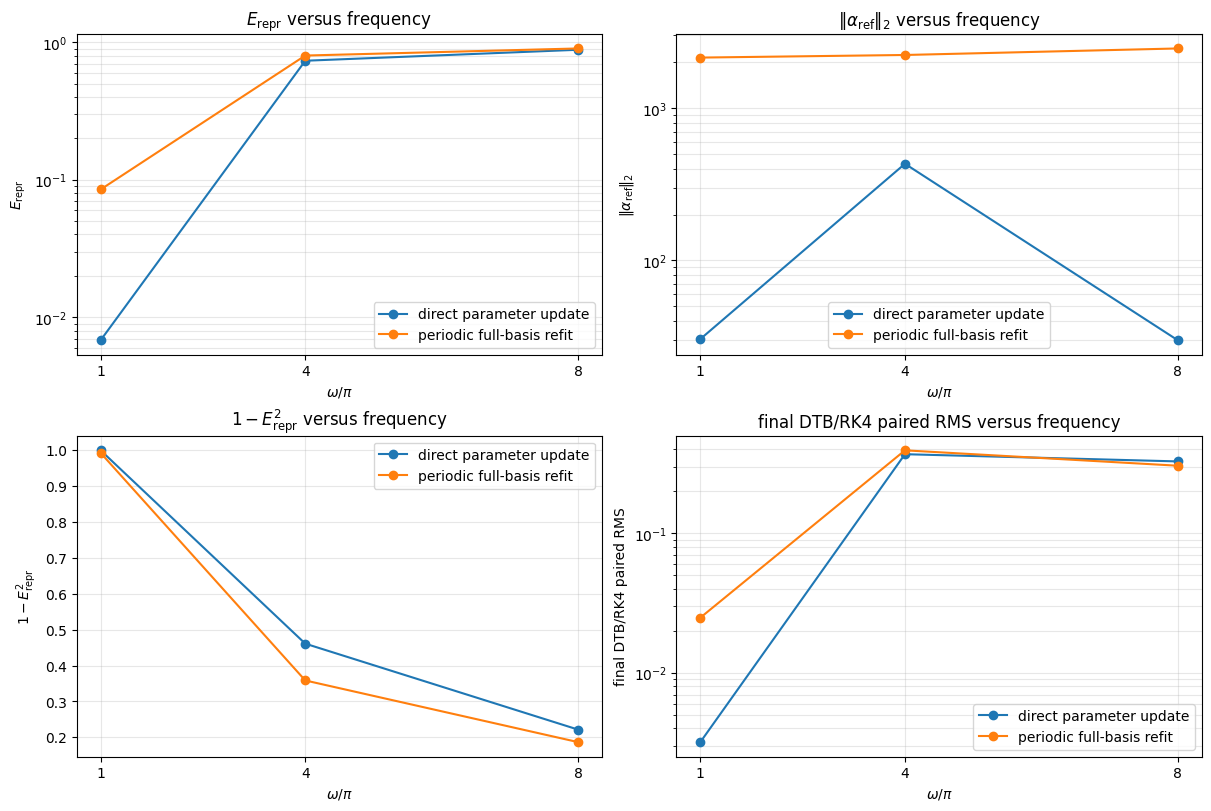

saved: /storage/home/hcoda1/7/msun351/DTB_Ver3/results/omega_direct_vs_periodic_refit/omega_sweep_diagnostics.png


In [4]:
rows = [dict(zip(columns, row)) for row in records]
methods = ('direct', 'periodic_refit')
colors = {'direct': 'tab:blue', 'periodic_refit': 'tab:orange'}
labels = {'direct': 'direct parameter update', 'periodic_refit': 'periodic full-basis refit'}

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
metric_specs = (
    ('representation_error', r'$E_{\mathrm{repr}}$', True),
    ('alpha_norm', r'$\|\alpha_{\mathrm{ref}}\|_2$', True),
    ('captured_energy', r'$1-E_{\mathrm{repr}}^2$', False),
    ('final_trajectory_rms', 'final DTB/RK4 paired RMS', True),
)
for axis, (metric, ylabel, log_scale) in zip(axes.flat, metric_specs):
    for method in methods:
        method_rows = [row for row in rows if row['method'] == method]
        x = np.asarray([row['omega_multiple'] for row in method_rows], dtype=float)
        y = np.asarray([row[metric] for row in method_rows], dtype=float)
        axis.plot(x, y, marker='o', color=colors[method], label=labels[method])
    if log_scale:
        axis.set_yscale('log')
    axis.set(
        xlabel=r'$\omega/\pi$',
        ylabel=ylabel,
        title=f'{ylabel} versus frequency',
        xticks=OMEGA_MULTIPLIERS,
    )
    axis.grid(True, which='both', alpha=0.3)
    axis.legend()

diagnostics_plot = output_dir / 'omega_sweep_diagnostics.png'
fig.savefig(diagnostics_plot, dpi=180, bbox_inches='tight')
plt.show()
print('saved:', diagnostics_plot)

## 4. Final-time particle snapshots for every frequency

Each row uses one frequency and compares the final direct-update particles, periodic-refit particles, and their common RK4 solution. All three panels use the same paired particle indices and identical axis limits. The RMS in each DTB title is computed against the RK4 particles with the same initial labels.

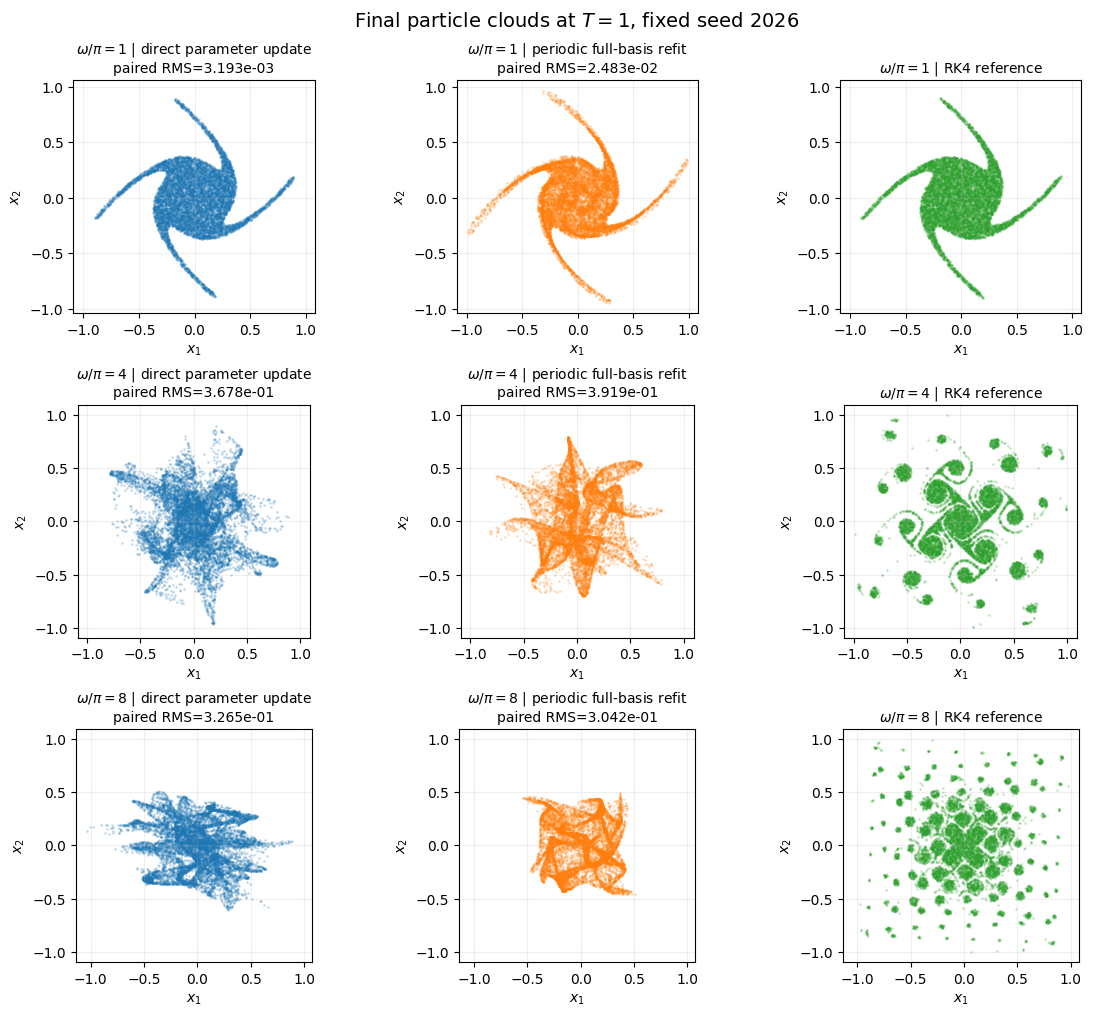

saved: /storage/home/hcoda1/7/msun351/DTB_Ver3/results/omega_direct_vs_periodic_refit/omega_sweep_final_particle_clouds.npz
saved: /storage/home/hcoda1/7/msun351/DTB_Ver3/results/omega_direct_vs_periodic_refit/omega_sweep_final_particle_snapshots.png


In [5]:
PLOT_MAX_POINTS = 10_000
cloud_archive = {}
for (multiplier, method), cloud in final_clouds.items():
    key = f'omega_{multiplier:g}_{method}'.replace('.', 'p')
    cloud_archive[key] = cloud
cloud_npz = output_dir / 'omega_sweep_final_particle_clouds.npz'
np.savez_compressed(cloud_npz, **cloud_archive)

fig, axes = plt.subplots(
    len(OMEGA_MULTIPLIERS),
    3,
    figsize=(11.5, 3.35 * len(OMEGA_MULTIPLIERS)),
    squeeze=False,
    constrained_layout=True,
)
column_titles = ('direct parameter update', 'periodic full-basis refit', 'RK4 reference')
column_methods = ('direct', 'periodic_refit', 'rk4')
column_colors = ('tab:blue', 'tab:orange', 'tab:green')

for row_index, multiplier in enumerate(OMEGA_MULTIPLIERS):
    clouds = tuple(
        final_clouds[(float(multiplier), method)]
        for method in column_methods
    )
    direct_cloud, periodic_cloud, rk4_cloud = clouds
    particle_count = rk4_cloud.shape[0]

    # A deterministic shared index set preserves particle pairing if subsampled.
    if particle_count <= PLOT_MAX_POINTS:
        plot_indices = np.arange(particle_count)
    else:
        plot_rng = np.random.default_rng(SEED + row_index)
        plot_indices = np.sort(
            plot_rng.choice(particle_count, PLOT_MAX_POINTS, replace=False)
        )

    # Use identical limits across all three methods in this frequency row.
    combined = np.concatenate(clouds, axis=0)
    lower = combined.min(axis=0)
    upper = combined.max(axis=0)
    span = np.maximum(upper - lower, 1e-12)
    padding = 0.05 * span

    direct_rms = np.sqrt(np.mean(np.sum((direct_cloud - rk4_cloud) ** 2, axis=1)))
    periodic_rms = np.sqrt(np.mean(np.sum((periodic_cloud - rk4_cloud) ** 2, axis=1)))
    panel_rms = (direct_rms, periodic_rms, None)

    for axis, cloud, title, color, rms in zip(
        axes[row_index], clouds, column_titles, column_colors, panel_rms
    ):
        shown = cloud[plot_indices]
        axis.scatter(
            shown[:, 0], shown[:, 1],
            s=3, alpha=0.30, color=color, linewidths=0, rasterized=True,
        )
        axis.set_xlim(lower[0] - padding[0], upper[0] + padding[0])
        axis.set_ylim(lower[1] - padding[1], upper[1] + padding[1])
        axis.set_aspect('equal', adjustable='box')
        axis.grid(True, alpha=0.20)
        axis.set_xlabel(r'$x_1$')
        axis.set_ylabel(r'$x_2$')
        rms_text = '' if rms is None else f'\npaired RMS={rms:.3e}'
        axis.set_title(
            rf'$\omega/\pi={multiplier:g}$ | {title}{rms_text}',
            fontsize=10,
        )

fig.suptitle(
    rf'Final particle clouds at $T={FINAL_TIME:g}$, fixed seed {SEED}',
    fontsize=14,
)
snapshot_plot = output_dir / 'omega_sweep_final_particle_snapshots.png'
fig.savefig(snapshot_plot, dpi=180, bbox_inches='tight')
plt.show()
print('saved:', cloud_npz)
print('saved:', snapshot_plot)

## 5. Reading the sweep

- Small $E_{\mathrm{repr}}$ means the final full tangent basis can reproduce the oscillatory target on the independent RK4 validation cloud.
- Large $\|\alpha_{\mathrm{ref}}\|_2$ means that representation requires a large parameter velocity; interpret a low error cautiously when this norm and the retained condition number are extreme.
- If periodic refitting lowers $E_{\mathrm{repr}}$ and the DTB/RK4 RMS, it has adapted the MMNN basis more effectively than direct parameter Euler updates.
- If both methods approach $E_{\mathrm{repr}}=1$ as $\omega$ increases, the shared MMNN architecture lacks the spatial resolution required by the high-frequency field.
- The final particle snapshots show whether a scalar RMS improvement also preserves the RK4 cloud geometry.

In [6]:
archive_path = Path(shutil.make_archive(
    str(output_dir),
    'zip',
    root_dir=output_dir,
))
print('result archive:', archive_path)

result archive: /storage/home/hcoda1/7/msun351/DTB_Ver3/results/omega_direct_vs_periodic_refit.zip
